In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00


In [ ]:
api_key = getpass("Enter your Roboflow API key: ")
os.environ["ROBOFLOW_API_KEY"] = api_key

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("janet-437bc").project("skin-disease-detection-kcpsj")
version = project.version(2)
dataset = version.download("folder")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to skin-disease-detection-2 in folder:: 100%|██████████| 24661/24661 [00:03<00:00, 8030.77it/s]


In [ ]:
import os
os.listdir("/content/skin-disease-detection-2")

['valid', 'README.dataset.txt', 'test', 'README.roboflow.txt', 'train']

In [ ]:
from ultralytics import YOLO

# Load classification model
model = YOLO("yolov8m-cls.pt")

# Train
model.train(
    data="/content/skin-disease-detection-2",
    epochs=50,
    imgsz=320,
    batch=32
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/skin-disease-detection-2, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7abf950c7410>
curves: []
curves_results: []
fitness: 0.8235724866390228
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7210834622383118, 'metrics/accuracy_top5': 0.9260615110397339, 'fitness': 0.8235724866390228}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.19619841580874245, 'inference': 1.6997881896062645, 'loss': 0.015370502927905427, 'postprocess': 0.009344557831972775}
top1: 0.7210834622383118
top5: 0.9260615110397339

In [ ]:
from google.colab import files
files.download("runs/classify/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#testing the model
from google.colab import drive
drive.mount('/content/drive')

model = YOLO("runs/classify/train/weights/best.pt")
results = model.predict(
    source="/content/drive/MyDrive/Dataset dump/skin_disease/Psoriasis-Skin-Disease.jpg",
    save=True,
    conf=0.25
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

image 1/1 /content/drive/MyDrive/Dataset dump/skin_disease/Psoriasis-Skin-Disease.jpg: 320x320 Bullous 0.83, DrugEruption 0.14, Actinic_Keratosis 0.02, Lichen 0.01, Infestations_Bites 0.00, 8.3ms
Speed: 32.8ms preprocess, 8.3ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/classify/predict


(np.float64(-0.5), np.float64(1999.5), np.float64(1332.5), np.float64(-0.5))

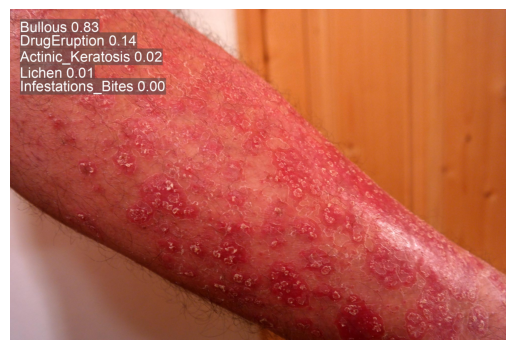

In [ ]:
#displaying the predicted image
from PIL import Image
import matplotlib.pyplot as plt

#test on a single object
img =Image.open(results[0].save_dir + '/'+ results[0].path.split('/')[-1])
plt.imshow(img)
plt.axis('off')

In [ ]:
#testing the modelon second image
# from google.colab import drive
# drive.mount('/content/drive')

model = YOLO("runs/classify/train/weights/best.pt")
results = model.predict(
    source="/content/drive/MyDrive/Dataset dump/skin_disease/psoriasis-GettyImages-1095587050-42ed6d9d90ae454abba9f0f1cabeb78e.jpg",
    save=True,
    conf=0.25
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

image 1/1 /content/drive/MyDrive/Dataset dump/skin_disease/psoriasis-GettyImages-1095587050-42ed6d9d90ae454abba9f0f1cabeb78e.jpg: 320x320 Psoriasis 0.95, Lichen 0.04, Warts 0.00, DrugEruption 0.00, Tinea 0.00, 8.2ms
Speed: 13.8ms preprocess, 8.2ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/classify/predict2


(np.float64(-0.5), np.float64(1499.5), np.float64(999.5), np.float64(-0.5))

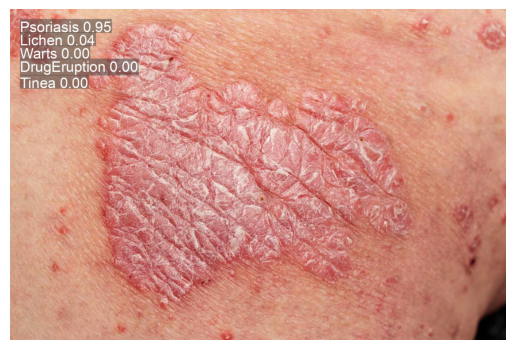

In [ ]:
#displaying the predicted image
from PIL import Image
import matplotlib.pyplot as plt

#test on a single object
img =Image.open(results[0].save_dir + '/'+ results[0].path.split('/')[-1])
plt.imshow(img)
plt.axis('off')

In [ ]:
#testing the modelon third image

model = YOLO("runs/classify/train/weights/best.pt")
results = model.predict(
    source="/content/drive/MyDrive/Dataset dump/skin_disease/pictures_of_warts_common_wart_1886207.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/drive/MyDrive/Dataset dump/skin_disease/pictures_of_warts_common_wart_1886207.jpg: 320x320 Warts 0.99, Vascular_Tumors 0.01, Infestations_Bites 0.00, Lichen 0.00, Seborrh_Keratoses 0.00, 8.3ms
Speed: 9.1ms preprocess, 8.3ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/classify/predict3


(np.float64(-0.5), np.float64(935.5), np.float64(701.5), np.float64(-0.5))

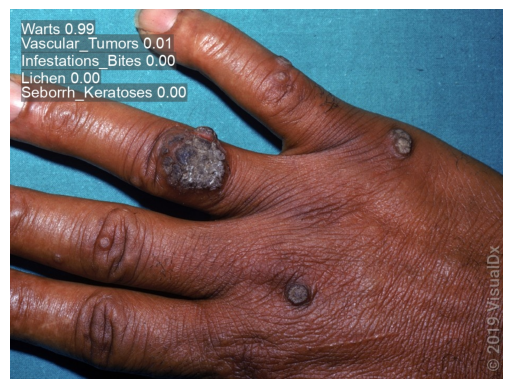

In [ ]:
#displaying the predicted image
from PIL import Image
import matplotlib.pyplot as plt

#test on a single object
img =Image.open(results[0].save_dir + '/'+ results[0].path.split('/')[-1])
plt.imshow(img)
plt.axis('off')

In [ ]:
#testing the modelon second image
# from google.colab import drive
# drive.mount('/content/drive')

model = YOLO("runs/classify/train/weights/best.pt")
results = model.predict(
    source="/content/drive/MyDrive/Dataset dump/skin_disease/GettyImages-1139022176-f54198ac12874807b83116ae1f0ed0c5.jpg",
    save=True,
    conf=0.25
)




image 1/1 /content/drive/MyDrive/Dataset dump/skin_disease/GettyImages-1139022176-f54198ac12874807b83116ae1f0ed0c5.jpg: 320x320 Acne 1.00, Bullous 0.00, Infestations_Bites 0.00, Actinic_Keratosis 0.00, Rosacea 0.00, 8.2ms
Speed: 61.5ms preprocess, 8.2ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/classify/predict4


(np.float64(-0.5), np.float64(3263.5), np.float64(2447.5), np.float64(-0.5))

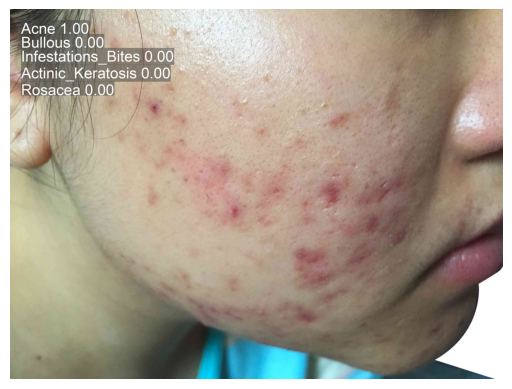

In [ ]:
#displaying the predicted image
from PIL import Image
import matplotlib.pyplot as plt

#test on a single object
img =Image.open(results[0].save_dir + '/'+ results[0].path.split('/')[-1])
plt.imshow(img)
plt.axis('off')